# Epitope query

This notebook will demonstrate how to query epitopes in `Dandelion` against public API including the IEDB (Immune Epitope Database) and VDJdb.

In [ ]:
import dandelion as ddl
import scanpy as sc
import warnings
import os

warnings.filterwarnings("ignore")

os.chdir("dandelion_tutorial")

First, we will load in the results from the TCR tutorial. If you have not run the TCR tutorial, please do so first.

In [2]:
vdj = ddl.read_zipddl("dandelion_results_tcr.zipddl")  # from the tcr tutorial
vdj

Lazy Dandelion object with n_obs = 6094 and n_contigs = 11300
    data: cell_id, sequence_id, sequence, sequence_aa, productive, rev_comp, v_call, v_cigar, d_call, d_cigar, j_call, j_cigar, c_call, c_cigar, sequence_alignment, germline_alignment, junction, junction_aa, junction_length, junction_aa_length, v_sequence_start, v_sequence_end, d_sequence_start, d_sequence_end, j_sequence_start, j_sequence_end, c_sequence_start, c_sequence_end, consensus_count, umi_count, is_cell, locus, rearrangement_status, extra, ambiguous, clone_id
    metadata: cell_id, clone_id, clone_id_rank, productive_VDJ, productive_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, junction_VDJ, junction_VJ, junction_aa_VDJ, junction_aa_VJ, locus_VDJ, locus_VJ, umi_count_VDJ, umi_count_VJ, productive_VDJ_main, productive_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, junction_VDJ_main, junction_VJ_main, 

In [3]:
adata = sc.read_h5ad("adata_tcr.h5ad")
adata

AnnData object with n_obs × n_vars = 17275 × 2305
    obs: 'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'scrublet_score', 'is_doublet', 'filter_rna', 'has_contig', 'productive_VDJ', 'productive_VJ', 'v_call_VDJ', 'v_call_VJ', 'd_call_VDJ', 'j_call_VDJ', 'j_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'junction_VDJ', 'junction_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'locus_VDJ', 'locus_VJ', 'umi_count_VDJ', 'umi_count_VJ', 'productive_VDJ_main', 'productive_VJ_main', 'v_call_VDJ_main', 'v_call_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'junction_VDJ_main', 'junction_VJ_main', 'junction_aa_VDJ_main', 'junction_aa_VJ_main', 'locus_VDJ_main', 'locus_VJ_main', 'umi_count_VDJ_main', 'umi_count_VJ_main', 'locus_status', 'chain_status', 'rearrangement_status_VDJ', 'rearrangement_status_VJ', 'leiden', 'clone_id', 'clone_id_rank'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions',

In [4]:
ddl.tl.clone_size(vdj)
ddl.tl.transfer(adata, vdj)

Next, we can query the epitopes in the `Dandelion` results against the IEDB and VDJdb databases. The results will be returned as a Pandas DataFrame, which can be further analyzed or visualized.

In [5]:
ddl.tl.get_epitope(vdj, adata, receptor_type="TCR", database="vdjdb")

INFO: get_epitope: database=vdjdb, receptor_type=TCR, chain=None
INFO: Resolved VDJdb release URL via latest-version.txt: https://github.com/antigenomics/vdjdb-db/releases/download/2026-05-16/vdjdb-2026-05-16.zip
INFO: Fetching VDJdb from https://github.com/antigenomics/vdjdb-db/releases/download/2026-05-16/vdjdb-2026-05-16.zip …
INFO: Downloaded 34643377 bytes from https://github.com/antigenomics/vdjdb-db/releases/download/2026-05-16/vdjdb-2026-05-16.zip
INFO: Parsing VDJdb file: vdjdb-2026-05-16/vdjdb.txt
INFO: VDJdb: 25263 rows after score filter (>=1)
INFO: VDJdb: 25263 rows after receptor_type filter 'TCR'
INFO: VDJdb: returning 25263 records


The results of the epitope query is mapped to `vdj.metadata` as well as `adata.obs`. So then you can plot and interact with the results in the same way as you would with any other metadata in `Dandelion` or .obs in `Scanpy`. For example, you can plot the epitope query results on a UMAP or tSNE plot, or you can filter the results based on specific epitopes or other metadata.

... storing 'productive_VDJ' as categorical
... storing 'productive_VJ' as categorical
... storing 'v_call_VDJ' as categorical
... storing 'v_call_VJ' as categorical
... storing 'd_call_VDJ' as categorical
... storing 'j_call_VDJ' as categorical
... storing 'j_call_VJ' as categorical
... storing 'c_call_VDJ' as categorical
... storing 'c_call_VJ' as categorical
... storing 'junction_VDJ' as categorical
... storing 'junction_VJ' as categorical
... storing 'junction_aa_VDJ' as categorical
... storing 'junction_aa_VJ' as categorical
... storing 'locus_VDJ' as categorical
... storing 'locus_VJ' as categorical
... storing 'productive_VDJ_main' as categorical
... storing 'productive_VJ_main' as categorical
... storing 'v_call_VDJ_main' as categorical
... storing 'v_call_VJ_main' as categorical
... storing 'd_call_VDJ_main' as categorical
... storing 'j_call_VDJ_main' as categorical
... storing 'j_call_VJ_main' as categorical
... storing 'c_call_VDJ_main' as categorical
... storing 'c_call_VJ

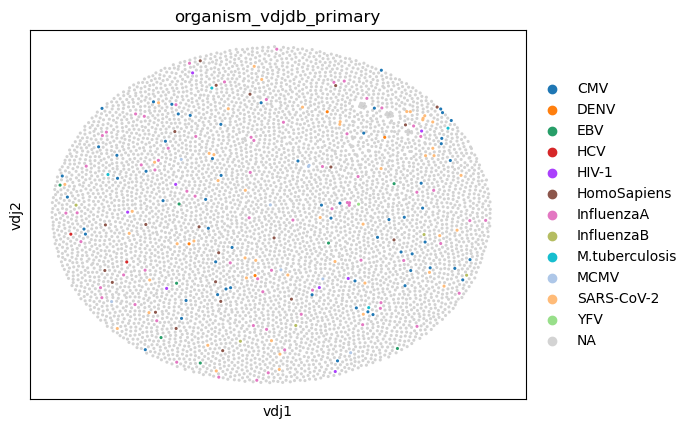

In [6]:
ddl.pl.clone_network(adata, color="organism_vdjdb_primary", size=20, edges=1)

In [ ]:
adata[adata.obs["organism_vdjdb_primary"] == "InfluenzaA"].obs[
    [
        "clone_id",
        "clone_id_size",
        "junction_aa_VDJ",
        "junction_aa_VJ",
        "epitope_vdjdb_primary",
        "organism_vdjdb_primary",
    ]
].sort_values("clone_id_size", ascending=False)

,clone_id,clone_id_size,junction_aa_VDJ,junction_aa_VJ,epitope_vdjdb_primary,organism_vdjdb_primary
sc5p_v2_hs_PBMC_10k_t_GCTTGAACAGGATCGA-1,abT_VDJ_323_1_3_VJ_34_1_3,3.0,CASSLGETQYF,CAVRPYGQNFVF,GILGFVFTL,InfluenzaA
sc5p_v2_hs_PBMC_10k_t_GTCGGGTGTCCAGTAT-1,abT_VDJ_323_1_3_VJ_34_1_3,3.0,CASSLGETQYF,CAVRPYGQNFVF,GILGFVFTL,InfluenzaA
sc5p_v2_hs_PBMC_10k_t_CTCAGAACACCACCAG-1,abT_VDJ_323_1_3_VJ_34_1_3,3.0,CASSLGETQYF,CAVRPYGQNFVF,GILGFVFTL,InfluenzaA
sc5p_v2_hs_PBMC_10k_t_GGATTACCATGACATC-1,abT_VDJ_276_2_6_VJ_564_2_1,1.0,CASSLTGGTEAFF,CAVQAYSGGGADGLTF,GILGFVFTL,InfluenzaA
sc5p_v2_hs_PBMC_10k_t_GTTCGGGAGGCCATAG-1,abT_VDJ_406_3_4_VJ_41_2_23,1.0,CASSDGTGGTDTQYF,CAVRDSNYQLIW,GILGFVFTL,InfluenzaA
...,...,...,...,...,...,...
sc5p_v2_hs_PBMC_10k_t_CTCGTCATCGTTGCCT-1,abT_VDJ_384_2_3_VJ_634_1_1,1.0,CASSERHATDTQYF,CAVPPDSWGKLQF,GILGFVFTL,InfluenzaA
sc5p_v2_hs_PBMC_10k_t_CTGAAACCAGACGCAA-1,abT_VDJ_493_5_1_VJ_413_1_1,1.0,CASSAEGDGSNEKLFF,CALNDYKLSF,GILGFVFTL,InfluenzaA
sc5p_v2_hs_PBMC_10k_t_CTGCCTAGTCGTCTTC-1,abT_VDJ_150_4_4_VJ_925_3_3,1.0,CASSPGLGQSYEQYF,CAATPSNTGKLIF,GILGFVFTL,InfluenzaA
sc5p_v2_hs_PBMC_10k_t_CTGCTGTCACTATCTT-1,abT_VDJ_323_1_1_VJ_34_1_2,1.0,CASSLGETQYF,CALRGYGQNFVF,GILGFVFTL,InfluenzaA
